✅ Models loaded: ['lstm_model', 'gru_model', 'bilstm_model', 'cnn_lstm_model', 'transformer_model']

── Per-model metrics ─────────────────────────────────────────────────
  lstm_model              RMSE=121.2279  MAE=115.0465  R²=-5.8050  MAPE=24.24%
  gru_model               RMSE=91.4955  MAE=86.9864  R²=-2.8764  MAPE=18.34%
  bilstm_model            RMSE=100.3203  MAE=92.7267  R²=-3.6602  MAPE=19.38%
  cnn_lstm_model          RMSE=87.2933  MAE=80.4445  R²=-2.5285  MAPE=16.80%
  transformer_model       RMSE=119.1597  MAE=108.4454  R²=-5.5748  MAPE=22.58%

  Ensemble                RMSE=103.7794  MAE=96.7299  R²=-3.9871  MAPE=20.27%

── Summary ───────────────────────────────────────────────────────────
                       RMSE       MAE      R2     MAPE
lstm_model         121.2279  115.0465 -5.8050  24.2397
gru_model           91.4955   86.9864 -2.8764  18.3409
bilstm_model       100.3203   92.7267 -3.6602  19.3835
cnn_lstm_model      87.2933   80.4445 -2.5285  16.8014
transformer_

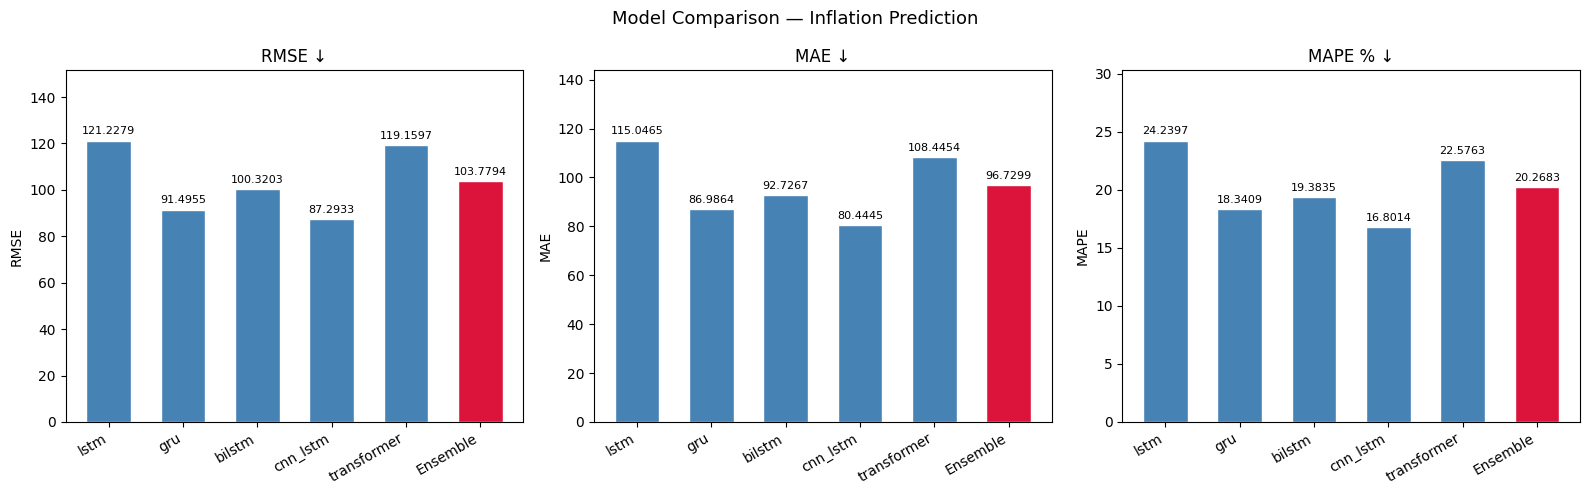

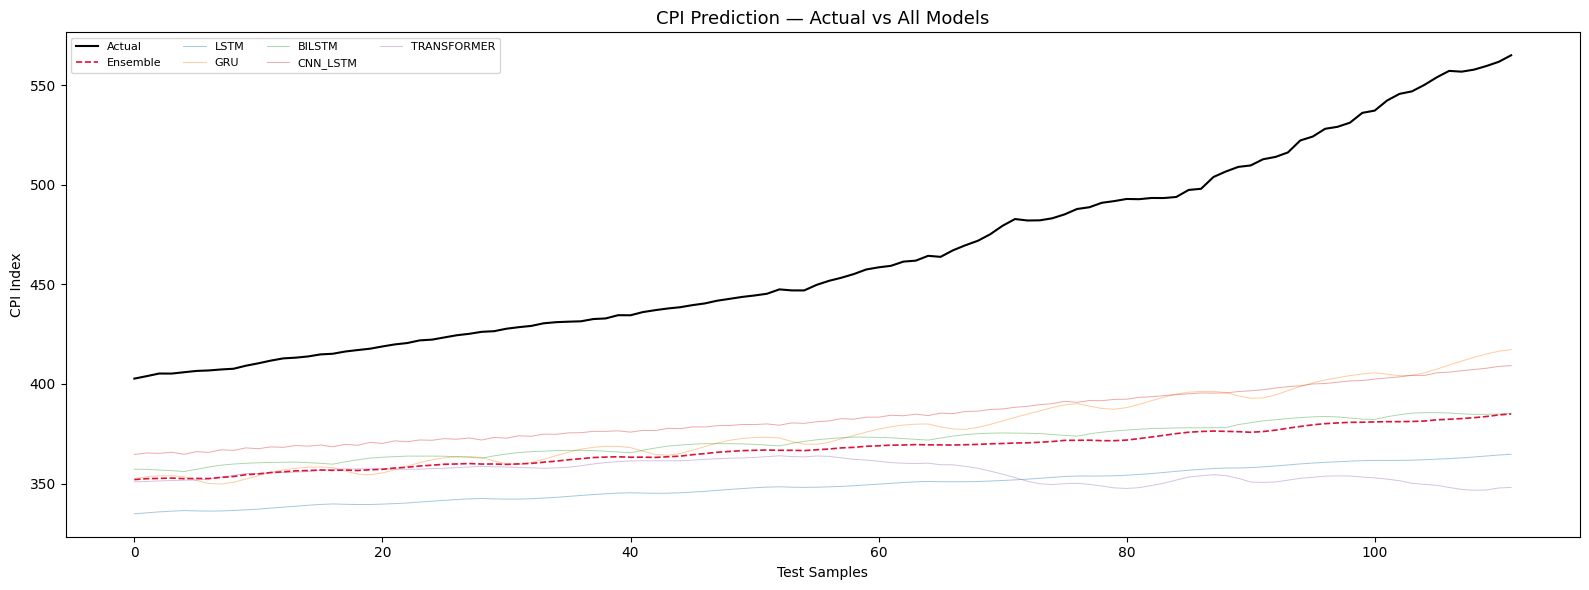

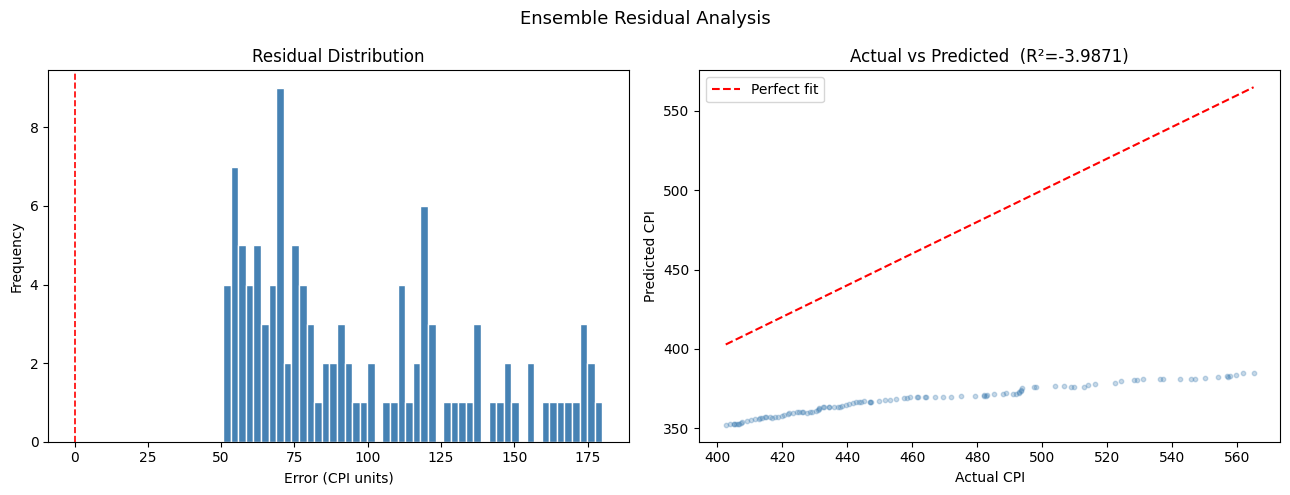


✅ Evaluation complete — plots saved to plots/


In [1]:
# ============================================================
#  NOTEBOOK 4 — Evaluation & Ensemble  (1 Cell)
# ============================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf

os.makedirs("plots", exist_ok=True)

# ── Load ──────────────────────────────────────────────────────────────────────
X_test   = np.load("data/X_test.npy")
y_test   = np.load("data/y_test.npy")
scaler_y = joblib.load("models/scaler_y.pkl")

MODEL_NAMES = ["lstm_model", "gru_model", "bilstm_model",
               "cnn_lstm_model", "transformer_model"]

def load_model(name):
    for ext in (".keras", ".h5"):
        path = f"models/{name}{ext}"
        if os.path.exists(path):
            return tf.keras.models.load_model(path)
    raise FileNotFoundError(f"Model not found: {name}")

models = {n: load_model(n) for n in MODEL_NAMES}
print("✅ Models loaded:", list(models.keys()))

# ── Evaluate ──────────────────────────────────────────────────────────────────
def evaluate(model, X_test, y_test, scaler_y, name):
    y_pred = scaler_y.inverse_transform(model.predict(X_test, verbose=0))
    y_true = scaler_y.inverse_transform(y_test)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    mape   = np.mean(np.abs((y_true - y_pred) /
                            (np.abs(y_true) + 1e-8))) * 100
    print(f"  {name:22s}  RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"R²={r2:.4f}  MAPE={mape:.2f}%")
    return y_pred.flatten(), y_true.flatten(), \
           {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

print("\n── Per-model metrics ─────────────────────────────────────────────────")
results, all_preds, y_true_ref = {}, {}, None

for name, model in models.items():
    pred, y_true, metrics = evaluate(model, X_test, y_test, scaler_y, name)
    results[name]   = metrics
    all_preds[name] = pred
    y_true_ref      = y_true

# ── Ensemble ──────────────────────────────────────────────────────────────────
y_true        = y_true_ref
ensemble_pred = np.mean(list(all_preds.values()), axis=0)
ens = {
    "RMSE": np.sqrt(mean_squared_error(y_true, ensemble_pred)),
    "MAE" : mean_absolute_error(y_true, ensemble_pred),
    "R2"  : r2_score(y_true, ensemble_pred),
    "MAPE": np.mean(np.abs((y_true - ensemble_pred) /
                           (np.abs(y_true) + 1e-8))) * 100
}
print(f"\n  {'Ensemble':22s}  RMSE={ens['RMSE']:.4f}  MAE={ens['MAE']:.4f}  "
      f"R²={ens['R2']:.4f}  MAPE={ens['MAPE']:.2f}%")

np.save("data/ensemble_pred.npy", ensemble_pred)
np.save("data/y_true.npy",        y_true)

# ── Metrics table ─────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(results).T
metrics_df.loc["Ensemble"] = ens
metrics_df = metrics_df[["RMSE","MAE","R2","MAPE"]].astype(float)
print("\n── Summary ───────────────────────────────────────────────────────────")
print(metrics_df.round(4).to_string())

# ── Plot 1: Metrics bar chart ─────────────────────────────────────────────────
labels = metrics_df.index.tolist()
short  = [l.replace("_model","") for l in labels]
colors = ["steelblue"] * len(MODEL_NAMES) + ["crimson"]
x      = np.arange(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — Inflation Prediction", fontsize=13)
for ax, col, title in zip(axes,
                           ["RMSE","MAE","MAPE"],
                           ["RMSE ↓","MAE ↓","MAPE % ↓"]):
    bars = ax.bar(x, metrics_df[col].values, color=colors,
                  edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=30, ha="right")
    ax.set_title(title); ax.set_ylabel(col)
    ax.set_ylim(0, metrics_df[col].max() * 1.25)

plt.tight_layout()
plt.savefig("plots/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Actual vs Predicted ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_true,        label="Actual",   color="black",   linewidth=1.5, zorder=5)
ax.plot(ensemble_pred, label="Ensemble", color="crimson", linewidth=1.2,
        linestyle="--", zorder=4)
for name, pred in all_preds.items():
    ax.plot(pred, linewidth=0.7, alpha=0.4,
            label=name.replace("_model","").upper())
ax.legend(ncol=4, fontsize=8)
ax.set_title("CPI Prediction — Actual vs All Models", fontsize=13)
ax.set_xlabel("Test Samples"); ax.set_ylabel("CPI Index")
plt.tight_layout()
plt.savefig("plots/cpi_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Residuals ─────────────────────────────────────────────────────────
errors = y_true - ensemble_pred
mn, mx = float(y_true.min()), float(y_true.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Ensemble Residual Analysis", fontsize=13)

axes[0].hist(errors, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Error (CPI units)")
axes[0].set_ylabel("Frequency")

axes[1].scatter(y_true, ensemble_pred, alpha=0.3, color="steelblue", s=10)
axes[1].plot([mn,mx],[mn,mx], "r--", linewidth=1.5, label="Perfect fit")
axes[1].set_title(f"Actual vs Predicted  (R²={ens['R2']:.4f})")
axes[1].set_xlabel("Actual CPI"); axes[1].set_ylabel("Predicted CPI")
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Evaluation complete — plots saved to plots/")